# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [18]:
# Import the library
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


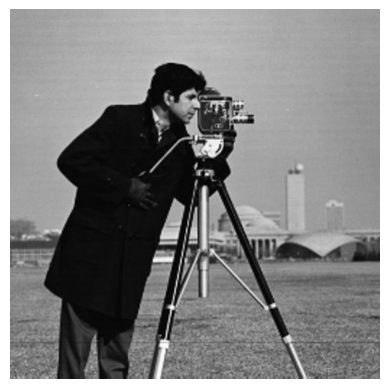

In [21]:
img = Image.open(r"C:\Users\Huawei\Downloads\cameraman.jpg")

# عرض الصورة
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [22]:
# Get the size of the image
width, height = img.size

# scaling factors
new_size = (width * 2, height * 2)


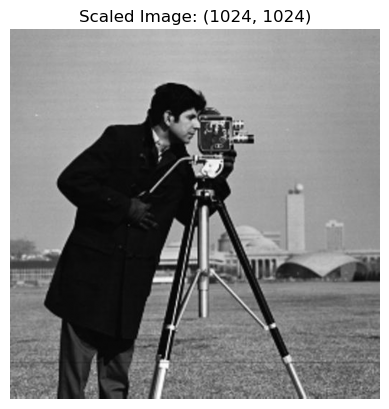

In [26]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

scaled_img = img.resize(new_size, resample=Image.LANCZOS)


plt.imshow(scaled_img, cmap='gray')
plt.title(f"Scaled Image: {scaled_img.size}")
plt.axis('off')
plt.show()



In [25]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

scaled_img.save("task1_1_scaled.jpg")


print(f"Original size: {img.size}")
print(f"New scaled size: {scaled_img.size}")
print("Image saved successfully as 'task1_1_scaled.jpg'")


Original size: (512, 512)
New scaled size: (1024, 1024)
Image saved successfully as 'task1_1_scaled.jpg'


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [27]:
cx, cy = 2, 1

In [28]:

new_width = int(width * cx)
new_height = int(height * cy)


stretched_img = img.resize((new_width, new_height), resample=Image.LANCZOS)

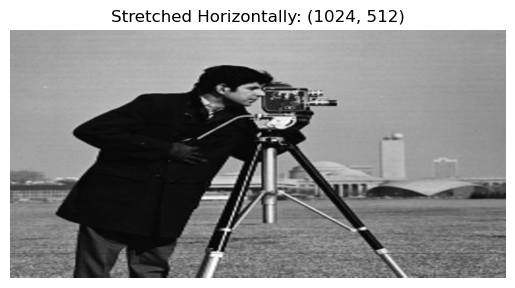

In [30]:

plt.imshow(stretched_img, cmap='gray')
plt.title(f"Stretched Horizontally: {stretched_img.size}")
plt.axis('off')
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated image size: (700, 700)
Image saved successfully as 'task1_2_rotated.jpg'


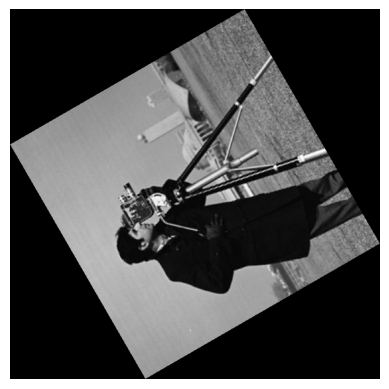

In [32]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_img = img.rotate(120, expand=True)

# 2. Save the rotated image with the required name
rotated_img.save("task1_2_rotated.jpg")

# 3. Print the sizes to confirm the transformation
print(f"Original size: {img.size}")
print(f"Rotated image size: {rotated_img.size}")
print("Image saved successfully as 'task1_2_rotated.jpg'")


plt.imshow(rotated_img, cmap='gray')
plt.axis('off')
plt.show()


### 3. Shear

In [46]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size


In [47]:
shear_factor = 0.5
shear_matrix = (1, shear_factor, 0, 0, 1, 0)

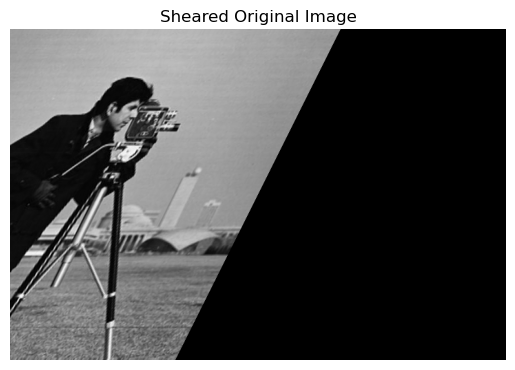

In [48]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]


new_width = int(width + abs(shear_factor * height))

sheared_img = img_original.transform((new_width, height), Image.AFFINE, shear_matrix, resample=Image.BICUBIC)

plt.imshow(sheared_img, cmap='gray')
plt.title("Sheared Original Image")
plt.axis('off')
plt.show()

In [43]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

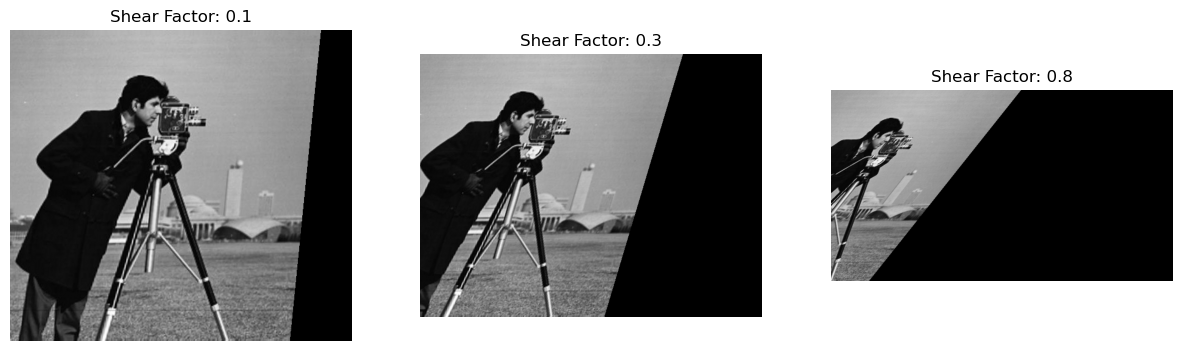

In [62]:
# تجربة قيم مختلفة: 0.1, 0.3, 0.8
factors = [0.1, 0.3, 0.8]

plt.figure(figsize=(15, 5))
for i, f in enumerate(factors):
    matrix = (1, f, 0, 0, 1, 0)
    new_w = int(width + abs(f * height))
    res = img.transform((new_w, height), Image.AFFINE, matrix, resample=Image.BICUBIC)
    
    plt.subplot(1, 3, i+1)
    plt.imshow(res, cmap='gray')
    plt.title(f"Shear Factor: {f}")
    plt.axis('off')
plt.show()

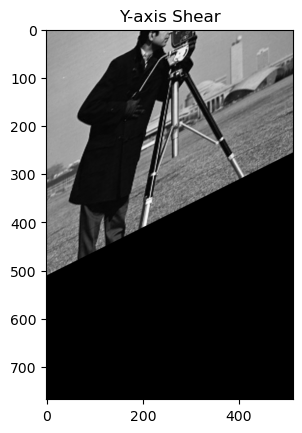

In [61]:
# Y-axis shear matrix
shy = 0.5
matrix_y = (1, 0, 0, shy, 1, 0)

new_h = int(height + abs(shy * width))
sheared_y = img.transform((width, new_h), Image.AFFINE, matrix_y, resample=Image.BICUBIC)

plt.imshow(sheared_y, cmap='gray')
plt.title("Y-axis Shear")
plt.show()

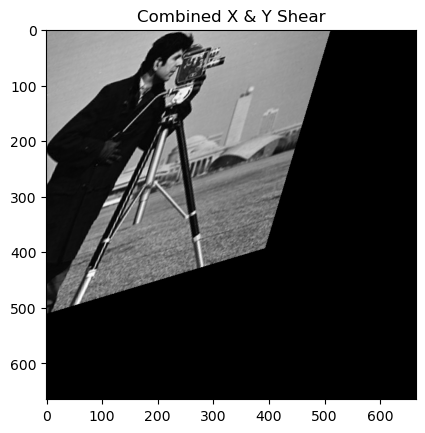

In [60]:
# Combining X and Y shear
shx, shy = 0.3, 0.3
combined_matrix = (1, shx, 0, shy, 1, 0)

new_w = int(width + abs(shx * height))
new_h = int(height + abs(shy * width))

combined_img = img.transform((new_w, new_h), Image.AFFINE, combined_matrix, resample=Image.BICUBIC)

plt.imshow(combined_img, cmap='gray')
plt.title("Combined X & Y Shear")
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

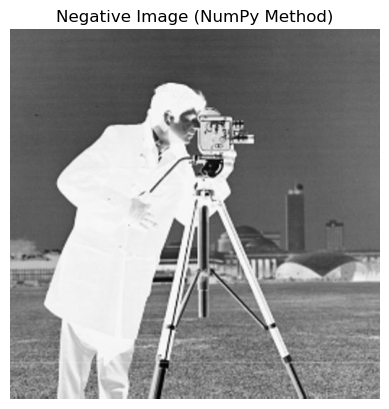

In [50]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
img_array = np.array(img)
negative_array = 255 - img_array


negative_img_v1 = Image.fromarray(negative_array.astype('uint8'))


plt.imshow(negative_img_v1, cmap='gray')
plt.title("Negative Image (NumPy Method)")
plt.axis('off')
plt.show()



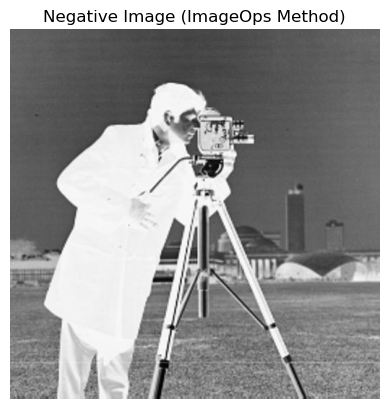

In [52]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_img_v2 = ImageOps.invert(img)

 
plt.imshow(negative_img_v2, cmap='gray')
plt.title("Negative Image (ImageOps Method)")
plt.axis('off')
plt.show()

negative_img_v2.save("task2_1_negative.jpg")

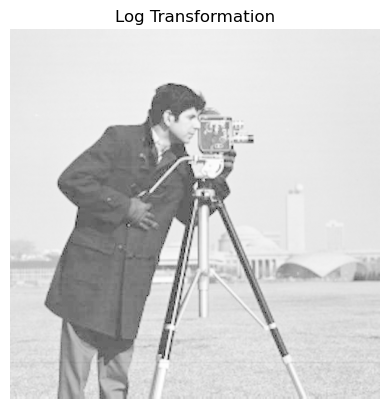

In [54]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel

import numpy as np

c = 255 / np.log(1 + 255)


img_array = np.array(img).astype(float)
log_transformed = c * np.log(1 + img_array)

log_img = np.array(log_transformed, dtype=np.uint8)

plt.imshow(log_img, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')
plt.show()

Image.fromarray(log_img).save("task2_2_log.jpg")


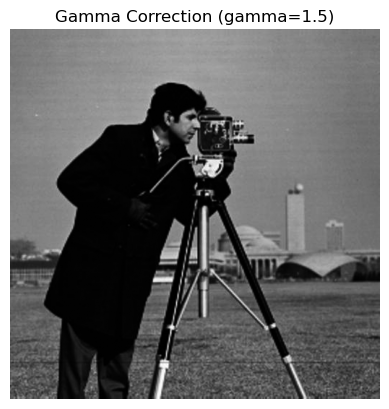

In [56]:

# ── 3. Power-law / Gamma correction ───────────────

gamma = 1.5 
c = 255 / (255**gamma)

img_array = np.array(img).astype(float)
gamma_transformed = c * (img_array**gamma)

gamma_img = np.array(gamma_transformed, dtype=np.uint8)

plt.imshow(gamma_img, cmap='gray')
plt.title(f"Gamma Correction (gamma={gamma})")
plt.axis('off')
plt.show()

Image.fromarray(gamma_img).save("task2_3_gamma.jpg")
